In [1]:
# Import the necessary libraries needed for this 
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,accuracy_score,classification_report,confusion_matrix,r2_score

In [2]:
# Before we move on note that :
# Note that RandomForestClassifier is a subset of BaggingClassifier which can be done on any classifier algorithm
'''
Difference Between Bagging and Random Forest : 
    Difference ...Random Forest is an extension of Bagging Classifier specifically designed for decision trees,
   introducing extra randomness by selecting random subsets of features at each split to create uncorrelated, diverse trees. 
   While Bagging can use any model, Random Forest reduces variance more effectively than standard bagging, resulting in better predictive performance

    Some Differences : 
   
    Core Principle: Bagging builds independent models on bootstrap samples (random subsets of data).
    Random Forest does this and selects a random subset of features for each tree split.
    Randomness Source: Bagging uses only row sampling (bootstrapping). Random Forest uses both row sampling and feature sampling.
    Base Estimator: Bagging Classifier can use any algorithm (e.g., SVM, Logistic Regression). Random Forest is exclusively for Decision Trees.
    Correlation: Because of feature randomness, Random Forest trees are less correlated than generic Bagging trees, 
    providing better variance reduction and overfitting protection.
    Hyperparameters: Random Forest includes max_features (size of feature subset) to control the randomness, which standard Bagging usually lacks.
'''

'\nDifference Between Bagging and Random Forest : \n    Difference ...Random Forest is an extension of Bagging Classifier specifically designed for decision trees,\n   introducing extra randomness by selecting random subsets of features at each split to create uncorrelated, diverse trees. \n   While Bagging can use any model, Random Forest reduces variance more effectively than standard bagging, resulting in better predictive performance\n\n    Some Differences : \n\n    Core Principle: Bagging builds independent models on bootstrap samples (random subsets of data).\n    Random Forest does this and selects a random subset of features for each tree split.\n    Randomness Source: Bagging uses only row sampling (bootstrapping). Random Forest uses both row sampling and feature sampling.\n    Base Estimator: Bagging Classifier can use any algorithm (e.g., SVM, Logistic Regression). Random Forest is exclusively for Decision Trees.\n    Correlation: Because of feature randomness, Random Fores

In [ ]:
df = pd.read_csv('adult.csv') 
# Import the dataset , here we are using a datasets of working adults and we will be making predicitions on the income column which
# is not numerical continous unlike standard datasets and is divided into bins categories here.

In [ ]:
df.head() # Skim the head to get an overall understanding of the dataset.

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
df.info() # Check the datatypes , missing rows , dtypes and other things using this function.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
df.describe() # Check for any irregularities or any special observation found in here which describes some anamoly or unique case. 

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.columns # The list of columns to be used when applying operations on multiple columns in parallel

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [ ]:
# A simple for loop which I made to check the unique values of the categorical columns and which encoding to use with them.
for x in ['workclass','education','marital-status', 'occupation', 'relationship', 'race', 'gender','native-country','income'] :

    if len(df[x]) > 10:
        print(x)
        print()
        print(df[x].unique())
        print()


workclass

['Private' 'Local-gov' '?' 'Self-emp-not-inc' 'Federal-gov' 'State-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

education

['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' 'Doctorate' '5th-6th' 'Assoc-voc' '9th'
 '12th' '1st-4th' 'Preschool']

marital-status

['Never-married' 'Married-civ-spouse' 'Widowed' 'Divorced' 'Separated'
 'Married-spouse-absent' 'Married-AF-spouse']

occupation

['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' '?'
 'Other-service' 'Prof-specialty' 'Craft-repair' 'Adm-clerical'
 'Exec-managerial' 'Tech-support' 'Sales' 'Priv-house-serv'
 'Transport-moving' 'Handlers-cleaners' 'Armed-Forces']

relationship

['Own-child' 'Husband' 'Not-in-family' 'Unmarried' 'Wife' 'Other-relative']

race

['Black' 'White' 'Asian-Pac-Islander' 'Other' 'Amer-Indian-Eskimo']

gender

['Male' 'Female']

native-country

['United-States' '?' 'Peru' 'Guatemala' 'Mexico' 'Dominican-Republic'
 'Ireland' 'Germany'

In [ ]:
df['gender'] # The gender column have two distinct values male and female which can be key-mapped .

0          Male
1          Male
2          Male
3          Male
4        Female
          ...  
48837    Female
48838      Male
48839    Female
48840      Male
48841    Female
Name: gender, Length: 48842, dtype: object

In [10]:
df['gender'] = df['gender'].map(
                                    {
                                                'Male' : 1,
                                                'Female' : 0
                                    }
)

In [ ]:
df['gender'] # Check whether the mapping was applied and confirm using the dtype below.

0        1
1        1
2        1
3        1
4        0
        ..
48837    0
48838    1
48839    0
48840    1
48841    0
Name: gender, Length: 48842, dtype: int64

In [ ]:
df = df.drop(columns='education') # We drop the education column (Even i dont remember why in future at the time of documentation but maybe for convenience)

In [ ]:
df.head() # Skim the dataset again

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,<=50K
1,38,Private,89814,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,<=50K
2,28,Local-gov,336951,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,>50K
3,44,Private,160323,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,>50K
4,18,?,103497,10,Never-married,?,Own-child,White,0,0,0,30,United-States,<=50K


In [ ]:
df = df.replace('?',np.nan) # We replace the '?' wherever found in the dataset with nan as we think it is not known and can be treated as nan value

In [ ]:
# Import pipeling libraries and the transformation libaries
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
from sklearn.impute import SimpleImputer

In [ ]:
'''
Theoretically, OrdinalEncoder should be reserved for features with a natural rank (like education or size). 
Using it on nominal data (like occupation or country) implies a fake order (e.g., "Doctor" is greater than "Farmer") that doesn't exist Scikit-Learn OrdinalEncoder Docs.
However, in Tree-Based Models (like your BaggingClassifier using DecisionTreeClassifier), we often "cheat" and use it for high-cardinality features for two practical reasons:
The "Sparsity" Problem: If you use OneHotEncoder on native-country, you add 40+ columns. If a tree splits on "Country_Greece", 
it only isolates a tiny fraction of data, making the split very weak Scikit-Learn OneHotEncoder Docs.
Tree Logic: Decision trees can perform multiple splits on a single numerical column to isolate specific integer values, 
effectively "finding" the categories even if the order is arbitrary.
'''

In [ ]:
# Based upon the analysis choose the columns to encode accordingly.
coloumns_for_ohe = ['workclass','marital-status','relationship','race']
columns_for_onc = ['occupation','native-country']

In [ ]:
# Instantiate the label encoder and make transformations 
le = LabelEncoder()
df['income'] = le.fit_transform(df['income'])

In [ ]:
df['income'] # Check whether the changes were reflected or not.

0        0
1        0
2        1
3        1
4        0
        ..
48837    0
48838    1
48839    0
48840    0
48841    1
Name: income, Length: 48842, dtype: int64

In [ ]:
df['income'].unique() # Check the cardinality

array([0, 1])

In [ ]:
from sklearn.ensemble import BaggingClassifier # Import the BaggingClassfier from ensemble module

In [ ]:
# Below is the pipeine we build using the strategy we discussed earlier.

In [ ]:
# The pipelines are then packed into the column transformer which will be again packed inside the main pipeline

In [22]:
onc_and_imputation= Pipeline([
                            ('simple_imputer',SimpleImputer(strategy='most_frequent')),
                            ('onc_encoder',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

In [23]:
ohe_and_imputation= Pipeline([
                            ('simple_imputer',SimpleImputer(strategy='most_frequent')),
                            ('onc_encoder',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])

In [24]:
preprocessor = ColumnTransformer(
                    transformers = [
                                        ('ohe',ohe_and_imputation,coloumns_for_ohe),
                                        ('onc',onc_and_imputation,columns_for_onc)
                    ],
        remainder = 'passthrough'
)

In [ ]:
main_pipe = Pipeline([
                            ('processor',preprocessor),
                            # The Set the model parameters
                            ('bgf',BaggingClassifier(               
                                                                        n_estimators = 100,
                                                                        n_jobs = -1,
                                                                        bootstrap = True, # Whether to boostrap samples or not
                                                                        # oob_score = True , # Returns the oob_score
                                                                        

                            ))
])

In [ ]:
# Split the dataset into predictors and predictions
X = df.drop(columns = ['income'])
y = df['income']

In [ ]:
# Split into training and testing set 
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
main_pipe # Check how data flows using the pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('processor', ...), ('bgf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('onc', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [ ]:
# Fit the pipeline and make predictions
main_pipe.fit(X_train,y_train)
y_pred = main_pipe.predict(X_test)

In [ ]:
# Check the cross val score
cvs = cross_val_score(
                    main_pipe,
                    X,
                    y,
                    cv = 10,
                    n_jobs=-1
)

In [ ]:
cvs.mean() # The cross val score mean

np.float64(0.8572746217884395)

In [ ]:
accuracy_score(y_test,y_pred) # The accuracy score of the predictions

0.8623195823523391

In [ ]:
print(classification_report(y_test,y_pred)) # The classification report demonstrating the model performance.

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      7479
           1       0.74      0.64      0.69      2290

    accuracy                           0.86      9769
   macro avg       0.82      0.79      0.80      9769
weighted avg       0.86      0.86      0.86      9769



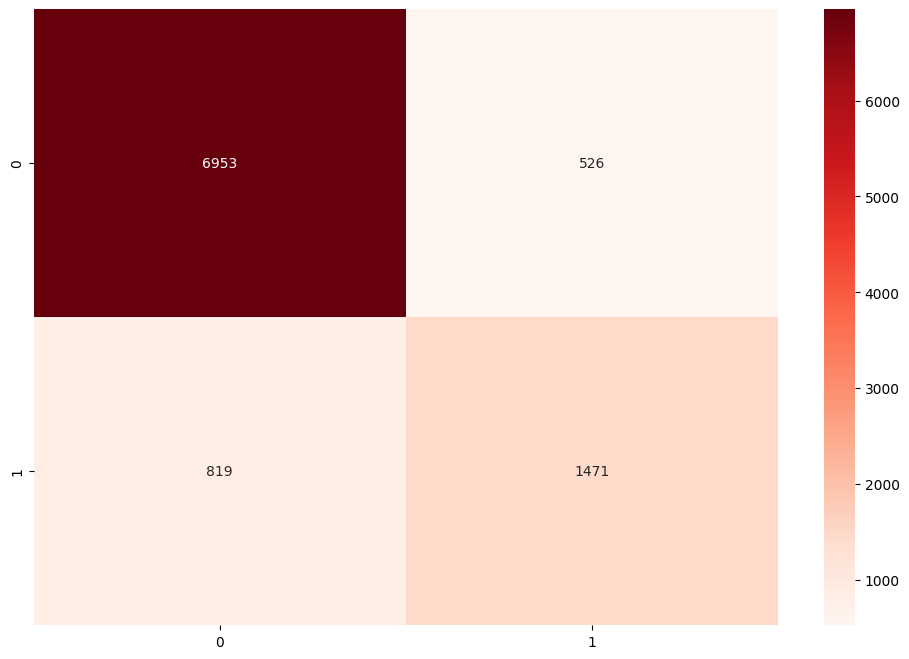

In [ ]:
# Plot the confusion matrix for this 
plt.figure(figsize=(12,8))
sns.heatmap(
                data = confusion_matrix(y_test,y_pred),
                cmap = 'Reds',
                annot = True,
                fmt = 'd'
)
plt.show()

In [ ]:
# BaggingRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

In [ ]:
df = pd.read_csv('insurance.csv')

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


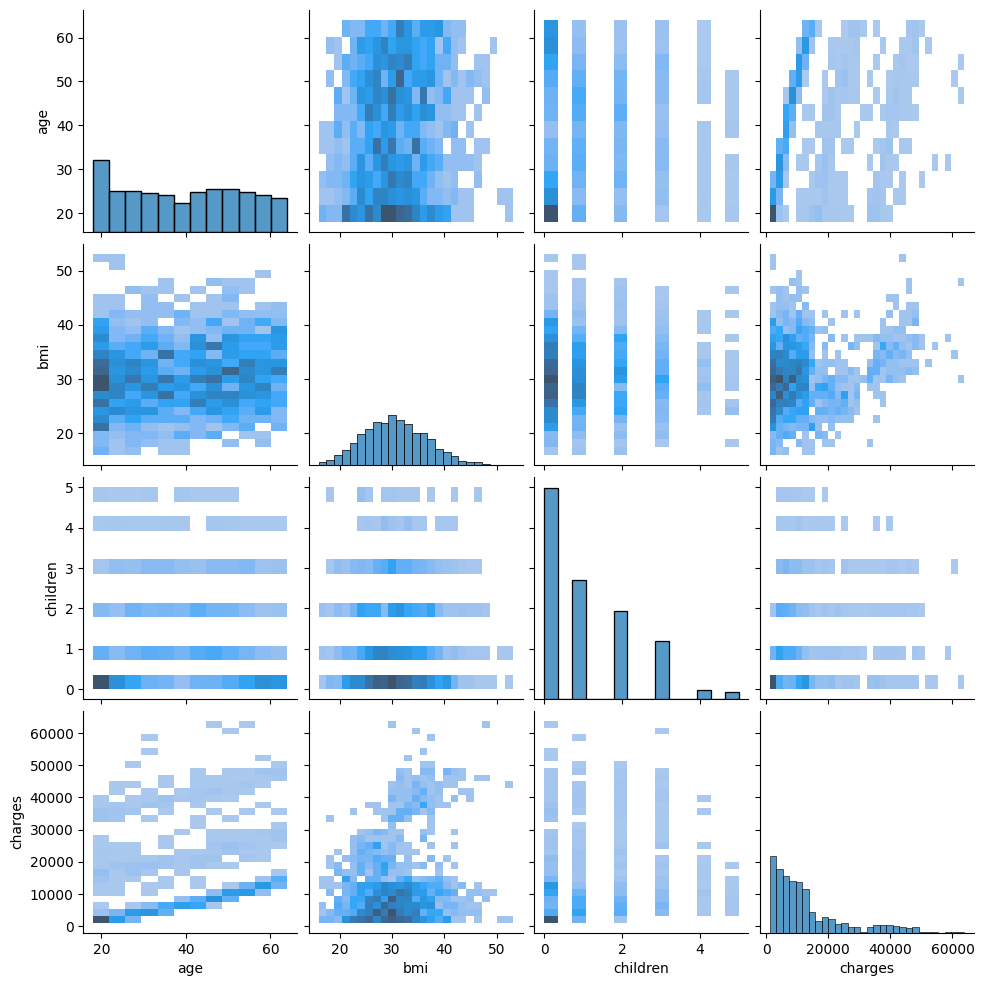

In [ ]:
sns.pairplot(
                data = df,
                kind = 'hist'
)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
for x in ['sex','smoker','region']:
    print(x)
    print(df[x].unique())
    print()

sex
['female' 'male']

smoker
['yes' 'no']

region
['southwest' 'southeast' 'northwest' 'northeast']



In [ ]:
df['sex'] = df['sex'].map(
                            {
                                'male' : 1,
                                'female' : 0
                            }
)

In [ ]:
df['smoker'] = df['smoker'].map(
                            {
                                'yes' : 1,
                                'no' : 0
                            }
)

In [ ]:
df.sample(3)

,age,sex,bmi,children,smoker,region,charges
1010,48,0,22.800,0,0,southwest,8269.04400
395,46,1,19.855,0,0,northwest,7526.70645
359,18,0,20.790,0,0,southeast,1607.51010


In [ ]:
from sklearn.preprocessing import OneHotEncoder
onc = OneHotEncoder(sparse_output=False)
new_regions = onc.fit_transform(df[['region']])

In [ ]:
new_regions

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], shape=(1338, 4))

In [ ]:
new_regions = pd.DataFrame(new_regions,columns=onc.get_feature_names_out())

In [ ]:
new_regions

,region_northeast,region_northwest,region_southeast,region_southwest
0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0
...,...,...,...,...
1333,0.0,1.0,0.0,0.0
1334,1.0,0.0,0.0,0.0
1335,0.0,0.0,1.0,0.0
1336,0.0,0.0,0.0,1.0


In [ ]:
df = pd.concat([df,new_regions],axis=1)

In [ ]:
df = df.drop(columns=['region'])

In [ ]:
df.head(3)

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.90,0,1,16884.9240,0.0,0.0,0.0,1.0
1,18,1,33.77,1,0,1725.5523,0.0,0.0,1.0,0.0
2,28,1,33.00,3,0,4449.4620,0.0,0.0,1.0,0.0


In [ ]:
X,y = df.drop(columns=['charges']) , df['charges']

In [ ]:
X

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0.0,0.0,0.0,1.0
1,18,1,33.770,1,0,0.0,0.0,1.0,0.0
2,28,1,33.000,3,0,0.0,0.0,1.0,0.0
3,33,1,22.705,0,0,0.0,1.0,0.0,0.0
4,32,1,28.880,0,0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,0.0,1.0,0.0,0.0
1334,18,0,31.920,0,0,1.0,0.0,0.0,0.0
1335,18,0,36.850,0,0,0.0,0.0,1.0,0.0
1336,21,0,25.800,0,0,0.0,0.0,0.0,1.0


In [ ]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [ ]:
X_train , X_test , y_train , y_test = train_test_split( X , y , test_size = 0.2 , random_state = 5)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scalled = scaler.fit_transform(X_train)
X_test_scalled = scaler.transform(X_test)

In [ ]:
bgr = BaggingRegressor(
                            estimator = DecisionTreeRegressor(
                                                                    max_depth = 10

                            ),
                            n_estimators = 25,
                            n_jobs = -1,
                            bootstrap = True,
                            bootstrap_features = True,
                            warm_start = True

)

In [ ]:
bgr.fit(X_train_scalled,y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...(max_depth=10)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",25
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",True
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [ ]:
y_pred_bgr = bgr.predict(X_test_scalled)

In [ ]:
y_pred_bgr

array([ 7356.04186893, 26062.73826206, 14094.08854597,  6852.41254338,
        9036.00688276, 35909.09805183, 12522.03311432, 10935.7101893 ,
       10010.25176985, 11707.86875962, 16193.6057453 , 13098.53210418,
        7797.44702798,  9267.57916747, 14160.82924131,  9551.95257111,
       25129.48154127, 12431.92303941, 11674.96966684,  7142.35459816,
       27401.89910395,  5069.64210172,  7228.90728558,  7743.08963504,
       11024.76914418,  8422.42291558, 36079.6711533 , 14555.63899404,
       12273.4969302 , 16339.20973881, 11564.25102311,  4101.62604188,
       12956.5583819 , 10702.61637531, 25366.75846037,  4225.04343147,
        7721.27904223,  4855.86862856,  6315.5411425 , 12006.83068874,
        5079.65256686, 27129.22904624, 29077.37869923, 25426.21458194,
       12517.47840018, 10004.15135316, 32824.0620479 ,  7226.1690202 ,
       16389.93705587,  7409.91493708,  6486.99379307, 20267.66834593,
        7595.3959567 ,  8792.23129406,  6421.37496825,  6959.67559166,
      

In [ ]:
mean_absolute_error(y_test,y_pred_bgr)

4584.501403546294

In [ ]:
root_mean_squared_error(y_test,y_pred_bgr)

6139.903411711092

In [ ]:
r2_score(y_test,y_pred_bgr)

0.7516390280531986

In [ ]:
residuals = y_test - y_pred_bgr

In [ ]:
residuals.sum()

np.float64(-290232.2986661162)

In [ ]:
cvs = cross_val_score(
                        bgr,
                        X,
                        y,
                        cv = 10,
                        n_jobs = -1
)

In [ ]:
cvs.mean()

np.float64(0.8288846072444682)

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
params =    {               
                            'estimator__max_depth' : [10],
                            "n_estimators" : [25,50],
                            'max_samples' : [0.5,1],
                            'max_features' : [0.5,1.0]
}

In [ ]:
gscv = GridSearchCV(
                        estimator = BaggingRegressor(estimator=DecisionTreeRegressor()),
                        n_jobs = -1,
                        param_grid = params,
                        cv = 10,
                        verbose=1
)

In [ ]:
gscv.fit(X,y)

Fitting 10 folds for each of 16 candidates, totalling 160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BaggingRegres...eeRegressor())
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__max_depth': [5, 10], 'max_features': [0.5, 1.0], 'max_samples': [0.5, 1], 'n_estimators': [25, 50]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

In [ ]:
bgr1 = gscv.best_estimator_

In [ ]:
gscv.best_index_

np.int64(5)

In [ ]:
gscv.best_params_

{'estimator__max_depth': 5,
 'max_features': 1.0,
 'max_samples': 0.5,
 'n_estimators': 50}

In [ ]:
gscv.best_score_

np.float64(0.8578526246264403)

In [ ]:
y_pred_bgr1 = bgr1.predict(X)

In [ ]:
mean_absolute_error(y,y_pred_bgr1)

2255.632391566418

In [ ]:
root_mean_squared_error(y,y_pred_bgr1)

4086.5004766944794

In [ ]:
r2_score(y,y_pred_bgr1)

0.8860435997926963